# Task 7: Clustering the Kick Dataset

This notebook profiles vehicles flagged as a 'kick' (bad buy) using clustering techniques.
The pipeline covers:
1. Data Preprocessing & Scaling
2. K-Means Clustering (Numeric variables only)
3. Cluster Visualization & Persona Labeling
4. K-Prototypes Clustering (Mixed data including 'Make')
5. Business Applications

## 1. Preprocessing

**Steps and Justification:**
*   **Missing Values:** Removed rows with missing data to prevent distance calculation errors in clustering. (The `kick_2` dataset has no missing values, so this step is a safety check rather than an active filter.)
*   **Anomaly Removal:** Removed rows with a `MMRAcquisitionAuctionAveragePrice` of $0. A vehicle cannot realistically have a $0 acquisition price, so these are treated as invalid data entries rather than genuine low-cost vehicles.
*   **Outlier Capping (IQR method):** K-Means relies on Euclidean distance, so a handful of extreme readings (e.g. a ~480,000-mile odometer) can pull centroids away from the bulk of the data. Values in `VehOdo`, `MMRAcquisitionAuctionAveragePrice`, and `WarrantyCost` beyond 1.5×IQR from the first/third quartiles are capped (winsorized) to the nearest bound, preserving all observations while limiting the influence of extreme values.
*   **Standardization (`StandardScaler`):** Clustering algorithms (like K-Means) use Euclidean distance. Variables like `VehOdo` (tens of thousands) would completely dominate `WarrantyCost` (hundreds) without scaling. Standardization gives all numerical features equal weight.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load dataset
df = pd.read_csv('kick_2.csv')

# 2. Handle missing values (Drop NaNs for robust distance metrics)
df = df.dropna().copy()

# 3. Handle anomalies: a $0 acquisition price is not a realistic value for a vehicle,
#    so these rows are treated as invalid data entries and removed.
n_before = len(df)
df = df[df['MMRAcquisitionAuctionAveragePrice'] > 0].copy()
print(f"Removed {n_before - len(df)} rows with an invalid (zero) acquisition price")

# 4. Handle outliers: cap extreme values in the continuous numeric columns using the IQR method,
#    since K-Means uses Euclidean distance and a handful of extreme readings could otherwise
#    pull cluster centroids away from the bulk of the data.
outlier_cols = ['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost']
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"Capped {n_capped} outliers in {col} to [{lower:.0f}, {upper:.0f}]")

# 5. Select attributes (excluding 'Make' for the first model)
num_features = ['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost', 'IsBadBuy']
X_num = df[num_features]

# 6. Apply Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

print("Shape of scaled numerical data:", X_scaled.shape)

Removed 502 rows with an invalid (zero) acquisition price
Capped 177 outliers in VehOdo to [30523, 113297]
Capped 310 outliers in MMRAcquisitionAuctionAveragePrice to [-861, 13005]
Capped 463 outliers in WarrantyCost to [-350, 2806]
Shape of scaled numerical data: (40907, 4)


## 2. Clustering Model (Excluding 'Make')

**Algorithm Chosen:** K-Means. It is highly efficient for purely numerical data and large datasets (~41k rows).
**Optimal K Method:** The Elbow Method (Inertia) combined with the Silhouette Score.

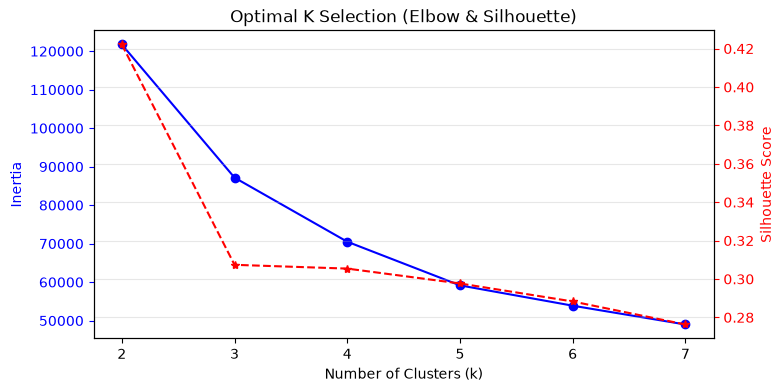

In [2]:
# Determine Optimal K
inertias = []
sil_scores = []
k_range = range(2, 8)

# Use a random sample for Silhouette score to reduce computation time
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=5000, replace=False)
X_sample = X_scaled[sample_indices]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

    labels_sample = km.predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, labels_sample))

# Plotting Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_range, inertias, 'bo-', label='Inertia')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'r*--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('Optimal K Selection (Elbow & Silhouette)')
plt.grid(True, alpha=0.3)
plt.show()

# Decision: K=3 provides a good balance (Inertia drop slows down, Silhouette remains reasonable).

In [3]:
# Fit Final K-Means Model (K=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_Num'] = kmeans.fit_predict(X_scaled)

# Report Centroids in Original Units
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroids = pd.DataFrame(centroids_orig, columns=num_features).round(2) + 0.0  # avoid displaying -0.0
df_centroids.index = [f"Cluster {i}" for i in range(optimal_k)]
df_centroids['Count'] = df['Cluster_Num'].value_counts().sort_index().values

print("=== Cluster Centroids (Original Units) ===")
print(df_centroids)

=== Cluster Centroids (Original Units) ===
             VehOdo  MMRAcquisitionAuctionAveragePrice  WarrantyCost  \
Cluster 0  80941.09                            6432.70       1591.13   
Cluster 1  74371.25                            5446.88       1320.71   
Cluster 2  60202.87                            6176.60        883.72   

           IsBadBuy  Count  
Cluster 0       0.0  18288  
Cluster 1       1.0   5300  
Cluster 2       0.0  17319  


## 3. Visualising and Interpreting Clusters

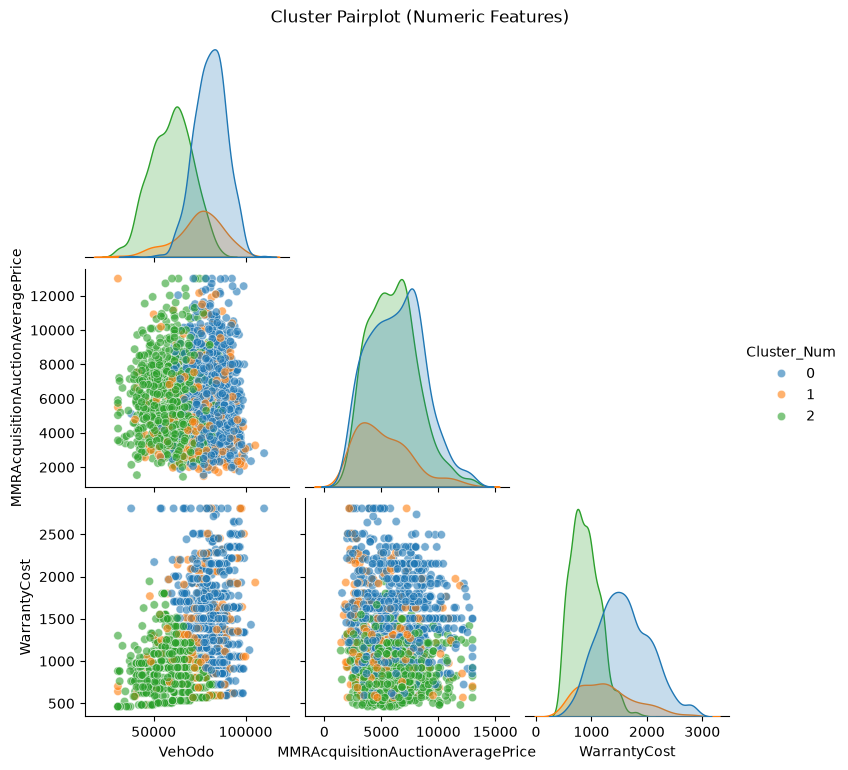

In [4]:
# Pairplot to visualize variable relationships and cluster boundaries
sample_for_plot = df.sample(n=2000, random_state=42) # Sample for clearer plotting
sns.pairplot(sample_for_plot, vars=['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost'],
             hue='Cluster_Num', palette='tab10', corner=True, plot_kws={'alpha':0.6})
plt.suptitle('Cluster Pairplot (Numeric Features)', y=1.02)
plt.show()

**Descriptive Cluster Labels:**
*   **Cluster 0 (High-Mileage, Premium Fleet):** The largest group (18,288 cars), with the highest odometer readings (~80,941 miles), the highest auction price (~$6,433), and the highest warranty cost (~$1,591) — yet a 0% `IsBadBuy` rate. These are older but well-priced/well-warrantied vehicles that still resell reliably.
*   **Cluster 1 (The "Kicks" / Bad Buys):** 5,300 cars characterized by a 100% `IsBadBuy` rate, the lowest auction price (~$5,447), and moderately high mileage (~74,371 miles). These are the definitive "bad buys" that the dealership struggles to resell.
*   **Cluster 2 (Low-Mileage, Budget Fleet):** 17,319 cars with the lowest mileage (~60,203 miles) and by far the lowest warranty cost (~$884), and a 0% `IsBadBuy` rate. The safest and cheapest-to-maintain segment.

**Caveat on `IsBadBuy` as a clustering feature:** Because `IsBadBuy` is binary and was standardized alongside the continuous features, K-Means separates on it almost perfectly (every cluster mean above is exactly 0.0 or 1.0). This means the model is not so much "discovering" a bad-buy segment as it is splitting the data on the known label first and then finding mileage/price/warranty structure within each side. The real profiling value here comes from how `VehOdo`, `MMRAcquisitionAuctionAveragePrice`, and `WarrantyCost` differ between the bad-buy and non-bad-buy sides, rather than from the cluster boundary itself.

## 4. Clustering Model (Including 'Make')

**Algorithm Chosen:** K-Prototypes. Since `Make` is a categorical string, standard K-Means cannot compute Euclidean distance on it. K-Prototypes elegantly handles mixed data by using Euclidean distance for numerical features and matching dissimilarity for categorical features.

In [5]:
!pip install kmodes -q
from kmodes.kprototypes import KPrototypes

# Extract numerical and categorical data
features_mixed = ['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost', 'IsBadBuy', 'Make']
df_mixed = df[features_mixed].copy()

# Scale numerical columns (indices 0 to 3)
df_mixed[num_features] = scaler.transform(df_mixed[num_features])

# Convert to matrix
X_mixed = df_mixed.values
categorical_idx = [4]  # 'Make' is at index 4

# Fit K-Prototypes
# Note: n_init and max_iter kept low for processing time in notebook execution.
kproto = KPrototypes(n_clusters=3, init='Cao', random_state=42, n_init=2, max_iter=20)
df['Cluster_Proto'] = kproto.fit_predict(X_mixed, categorical=categorical_idx)

# Analyze categorical centroids
print("=== K-Prototypes Cluster Centers ===")
for i, center in enumerate(kproto.cluster_centroids_):
    # Inverse transform the numeric part (indices 0 to 3)
    num_unscaled = scaler.inverse_transform([center[:4].astype(float)])[0]
    cat_val = center[4]
    print(f"Cluster {i}: Odo={num_unscaled[0]:.0f}, Price={num_unscaled[1]:.0f}, "
          f"Warranty={num_unscaled[2]:.0f}, BadBuy={num_unscaled[3]:.2f}, Make={cat_val}")


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


=== K-Prototypes Cluster Centers ===
Cluster 0: Odo=74371, Price=5447, Warranty=1321, BadBuy=1.00, Make=FORD
Cluster 1: Odo=80934, Price=6413, Warranty=1591, BadBuy=0.00, Make=CHEVROLET
Cluster 2: Odo=60230, Price=6197, Warranty=884, BadBuy=0.00, Make=DODGE


**Comparison with the Earlier K-Means Model**

When we add the Make variable using K-Prototypes, the cluster numbers change, but the core characteristics of each group remain the same:

Cluster 0 (Bad Buys): Vehicles in this group have the lowest auction price (around $5,447) and high mileage, but 100% of them are bad buys. FORD is the most common make here, showing that cheap, high-mileage Ford cars at auctions carry a very high risk of being a kick.

Cluster 1 (Older, High-Mileage Cars): Dominated by CHEVROLET, these cars have the highest mileage (over 80,000 miles) and the highest warranty cost ($1,591), but none of them are bad buys. They are older, everyday cars that require more maintenance but are still resalable.

Cluster 2 (Low-Risk Cars): Dominated by DODGE, these vehicles have low mileage (around 60,000 miles) and the lowest warranty cost ($884), with zero bad buys. They represent safe and reliable inventory.

While the first K-Means model only showed general numbers, the K-Prototypes model helps the dealership see which car brands are linked to high-risk or low-risk groups.

## 5. Practical Context for Decision-Makers

1. **Avoid Risky Auction Buys:**
Buyers should be very careful with cars that fit Cluster 0 (especially FORD models priced under $5,500 with over 70,000 miles). These cars have a high chance of being a bad buy, so the dealership should inspect them thoroughly before bidding or avoid them completely.

2. **Stock Reliable Inventory:**
Cars in Cluster 2 (mainly DODGE) are safe investments because they have low mileage and low warranty costs. The dealership can buy more of these cars to resell quickly to retail customers with little repair work.

3. **Plan for Warranty Costs:**
Cluster 1 cars (CHEVROLET) are not bad buys, but their average warranty cost is much higher ($1,591 compared to $884 for Cluster 2). The dealership should price these cars slightly higher to cover potential repair costs after the sale.